In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("used_car_price_dataset_extended.csv")

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())
display(df.isnull().sum())

Shape: (10000, 12)


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


None

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

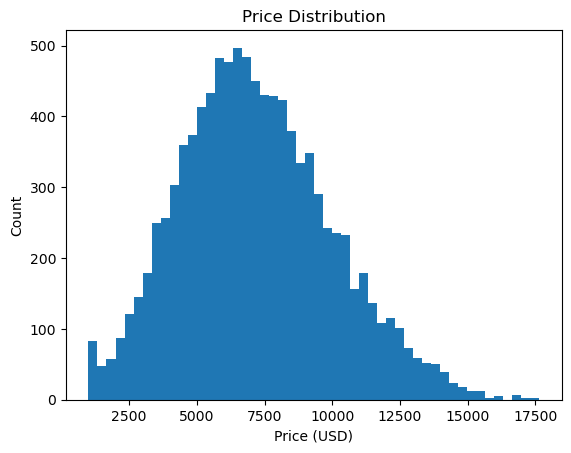

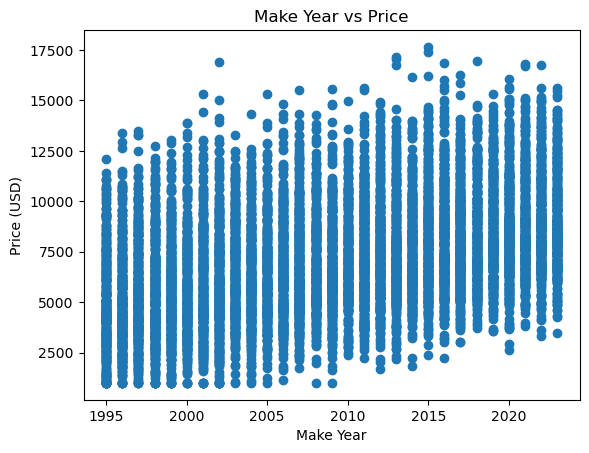

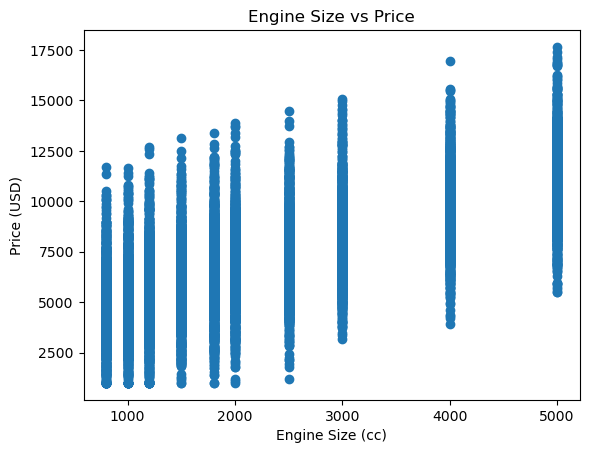

C:\Users\ryanm\AppData\Local\Temp\ipykernel_40496\2757379826.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


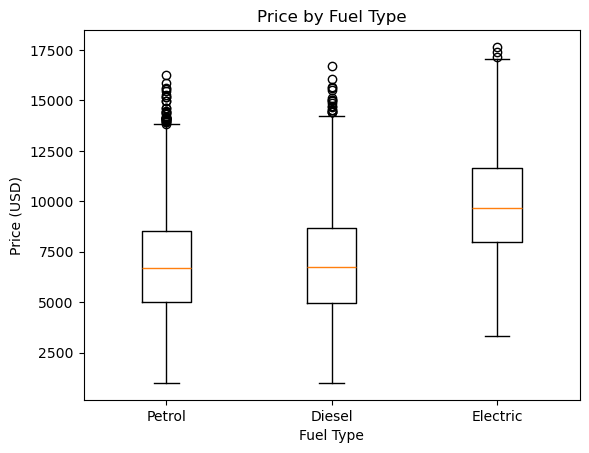

In [3]:
plt.hist(df['price_usd'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

plt.scatter(df['make_year'], df['price_usd'])
plt.title("Make Year vs Price")
plt.xlabel("Make Year")
plt.ylabel("Price (USD)")
plt.show()

plt.scatter(df['engine_cc'], df['price_usd'])
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (USD)")
plt.show()

plt.boxplot(
    [df[df['fuel_type'] == fuel]['price_usd'] for fuel in df['fuel_type'].unique()],
    labels=df['fuel_type'].unique()
)
plt.title("Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (USD)")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop('price_usd', axis=1)
y = df['price_usd']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [7]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    print(f"--- {name} ---")
    print("Validation MAE:", mean_absolute_error(y_val, val_preds))
    print("Validation RMSE:", mean_squared_error(y_val, val_preds) ** 0.5)
    print("Validation R2:", r2_score(y_val, val_preds))

    print("Test MAE:", mean_absolute_error(y_test, test_preds))
    print("Test RMSE:", mean_squared_error(y_test, test_preds) ** 0.5)
    print("Test R2:", r2_score(y_test, test_preds))
    print()

    return test_preds

In [10]:
lr_preds = evaluate_model("Linear Regression", lr_model)
ridge_preds = evaluate_model("Ridge Regression", ridge_model)
rf_preds = evaluate_model("Random Forest", rf_model)

--- Linear Regression ---
Validation MAE: 829.13862
Validation RMSE: 1033.9540378059849
Validation R2: 0.8631024256490034
Test MAE: 790.96973
Test RMSE: 990.650945499776
Test R2: 0.8766404943065323

--- Ridge Regression ---
Validation MAE: 829.1618885663466
Validation RMSE: 1034.0089894001912
Validation R2: 0.8630878738612369
Test MAE: 790.9690186061051
Test RMSE: 990.6658675013902
Test R2: 0.8766367779933041

--- Random Forest ---
Validation MAE: 901.1366900999999
Validation RMSE: 1112.5204169742042
Validation R2: 0.8415072993267394
Test MAE: 876.6091332000001
Test RMSE: 1091.2819400880048
Test R2: 0.8503057082791458



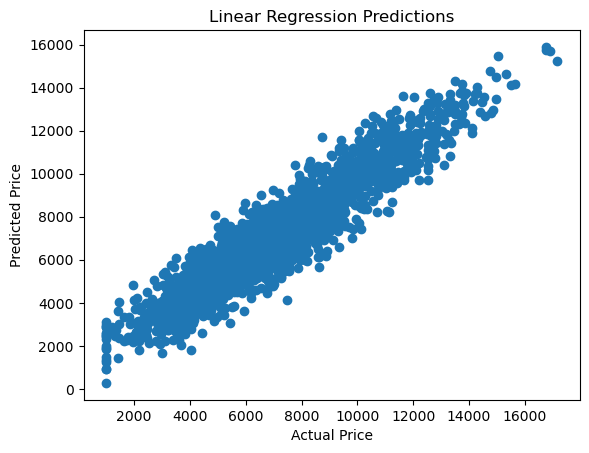

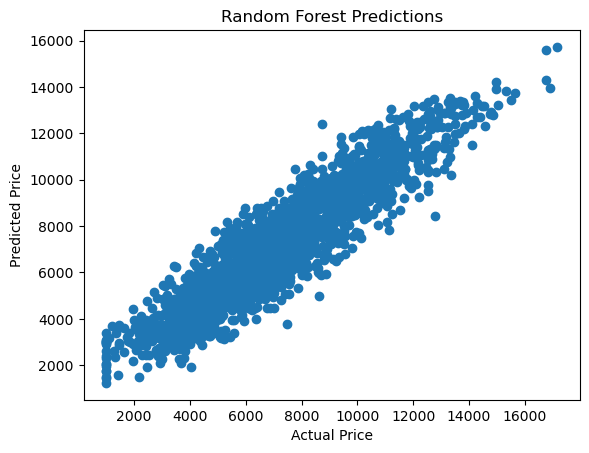

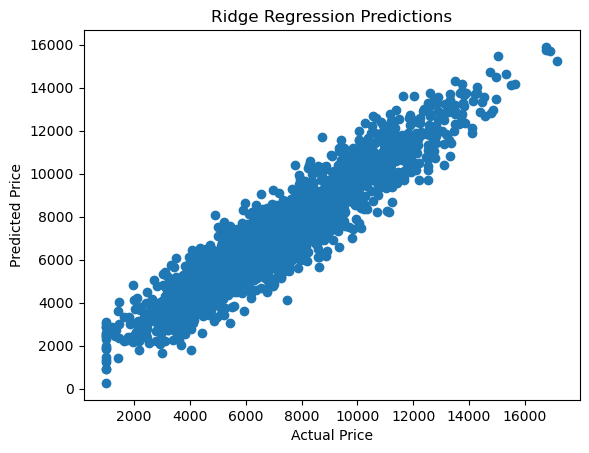

In [11]:
plt.scatter(y_test, lr_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Predictions")
plt.show()

plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")
plt.show()

plt.scatter(y_test, ridge_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression Predictions")
plt.show()

                      Feature  Importance
2              num__engine_cc    0.464062
0              num__make_year    0.213742
6     cat__fuel_type_Electric    0.103322
1           num__mileage_kmpl    0.082509
3            num__owner_count    0.064957
4     num__accidents_reported    0.005745
26  cat__service_history_Full    0.003158
10            cat__brand_Ford    0.003111
13             cat__brand_Kia    0.003073
25           cat__color_White    0.003069


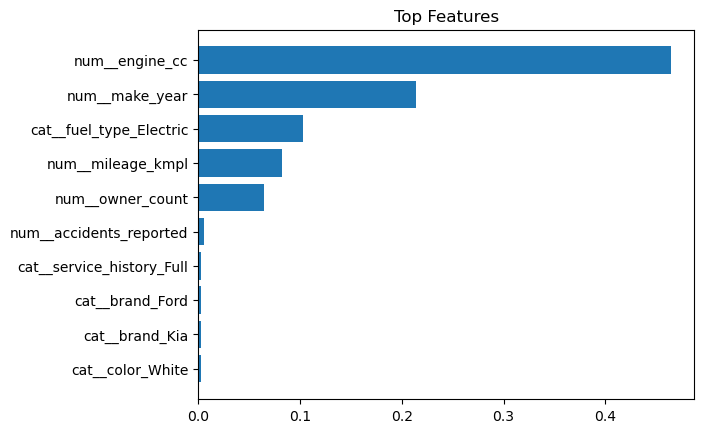

In [12]:
rf_model.fit(X_train, y_train)

feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

plt.barh(importance_df.head(10)["Feature"], importance_df.head(10)["Importance"])
plt.title("Top Features")
plt.gca().invert_yaxis()
plt.show()

In [13]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "Test MAE": [790.96973, 790.9690186061051, 876.6091332000001],
    "Test RMSE": [990.650945499776, 990.6658675013902, 1091.2819400880048],
    "Test R2": [0.8766404943065323, 0.8766367779933041, 0.8503057082791458]
})

display(results_df)

,Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,790.969730,990.650945,0.876640
1,Ridge Regression,790.969019,990.665868,0.876637
2,Random Forest,876.609133,1091.281940,0.850306


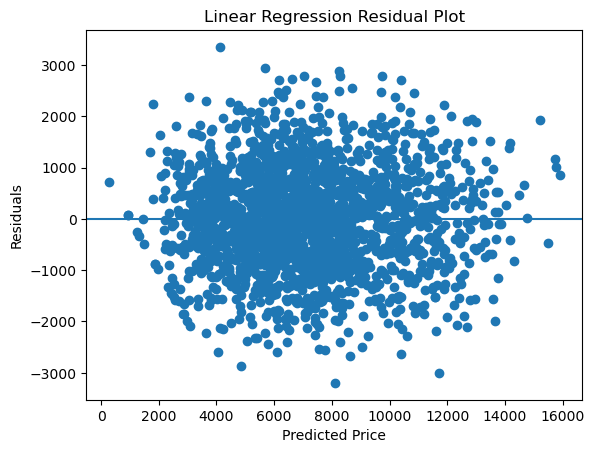

In [14]:
residuals = y_test - lr_preds

plt.scatter(lr_preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

In [17]:
X_reduced = X.drop(['engine_cc', 'make_year'], axis=1)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

numeric_features_r = X_reduced.select_dtypes(include=['int64', 'float64']).columns
categorical_features_r = X_reduced.select_dtypes(include=['object']).columns

preprocessor_r = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_r),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_r)
    ]
)

lr_model_r = Pipeline([
    ('preprocessor', preprocessor_r),
    ('model', LinearRegression())
])

lr_model_r.fit(X_train_r, y_train_r)
reduced_preds = lr_model_r.predict(X_test_r)

print("Original RMSE:", mean_squared_error(y_test, lr_preds) ** 0.5)
print("Reduced RMSE:", mean_squared_error(y_test_r, reduced_preds) ** 0.5)

Original RMSE: 990.650945499776
Reduced RMSE: 2498.883161014641


In [16]:
high_price_idx = y_test > 12000

print("Linear RMSE (high price):",
      mean_squared_error(y_test[high_price_idx], lr_preds[high_price_idx]) ** 0.5)

print("Random Forest RMSE (high price):",
      mean_squared_error(y_test[high_price_idx], rf_preds[high_price_idx]) ** 0.5)

Linear RMSE (high price): 1166.4826942938143
Random Forest RMSE (high price): 1472.7658805134274
